In [1]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS
# IMPORT REQUIRED LIBRARIES
# ==============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Load cleaned transaction data

transactions_df = pd.read_csv(
    "Fintrust_Transaction_Data_Cleaned.csv"
)

transactions_df.head()

,Transaction_ID,Customer_ID,Transaction_DateTime,Transaction_Type,Amount_NGN,Channel,Device_Type,Location,International_Transaction,Transaction_Status,Risk_Review_Flag
0,FT-T000001,FT-C01135,1/1/2026 0:00,Card Purchase,5923.80,Mobile App,Android,Enugu,No,Reversed,Yes
1,FT-T000002,FT-C00428,1/1/2026 0:10,Cash Withdrawal,11681.12,ATM,Android,Kaduna,No,Successful,Yes
2,FT-T000003,FT-C00469,1/1/2026 0:21,Transfer,571.91,ATM,POS Terminal,Kano,No,Successful,No
3,FT-T000004,FT-C01015,1/1/2026 0:32,Deposit,105367.52,Mobile App,Web Browser,Abuja,No,Successful,No
4,FT-T000005,FT-C00870,1/1/2026 0:43,Cash Withdrawal,3049.06,Mobile App,POS Terminal,Abuja,No,Successful,No


,Transaction_DateTime,Total_Transactions,Total_Transaction_Value
0,2026-01-01,4133,1.884894e+08
1,2026-02-01,3734,1.757869e+08
2,2026-03-01,4133,1.962010e+08


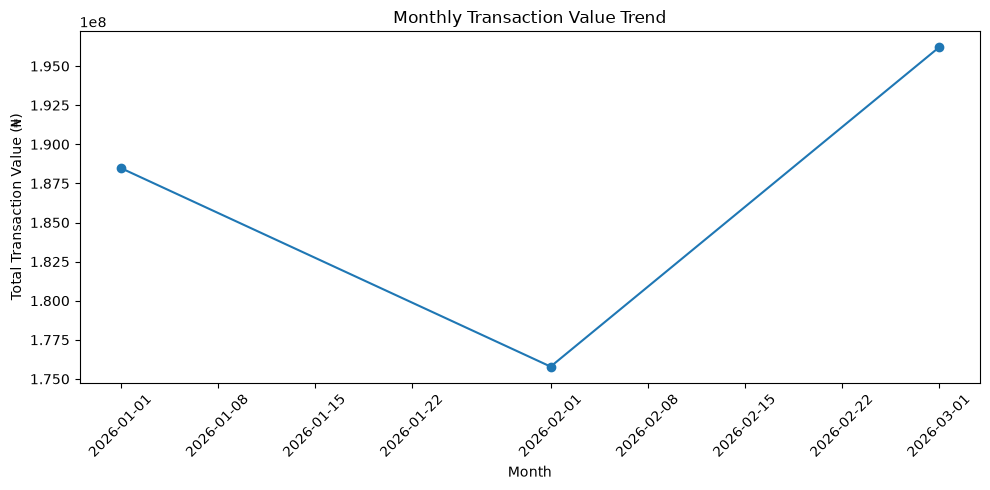

In [5]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS 1
# TITLE: Monthly Transaction Trend
# ==============================================================

# Convert transaction date to datetime
transactions_df['Transaction_DateTime'] = pd.to_datetime(
    transactions_df['Transaction_DateTime']
)

# Create monthly transaction summary
monthly_trend = (
    transactions_df
    .groupby(
        transactions_df['Transaction_DateTime'].dt.to_period('M')
    )
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),
        Total_Transaction_Value=('Amount_NGN', 'sum')
    )
    .reset_index()
)

# Convert month back to datetime
monthly_trend['Transaction_DateTime'] = (
    monthly_trend['Transaction_DateTime'].dt.to_timestamp()
)

# Display monthly results
display(monthly_trend)

# Plot monthly transaction value
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_trend['Transaction_DateTime'],
    monthly_trend['Total_Transaction_Value'],
    marker='o'
)

plt.title('Monthly Transaction Value Trend')
plt.xlabel('Month')
plt.ylabel('Total Transaction Value (₦)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Customer_Segment,Total_Transactions,Total_Transaction_Value,Average_Transaction_Amount
0,Everyday,5644,2.614589e+08,46325.11
1,Premium,2361,1.077512e+08,45637.95
3,Student,2289,1.074759e+08,46953.20
2,SME,1706,8.379137e+07,49115.69


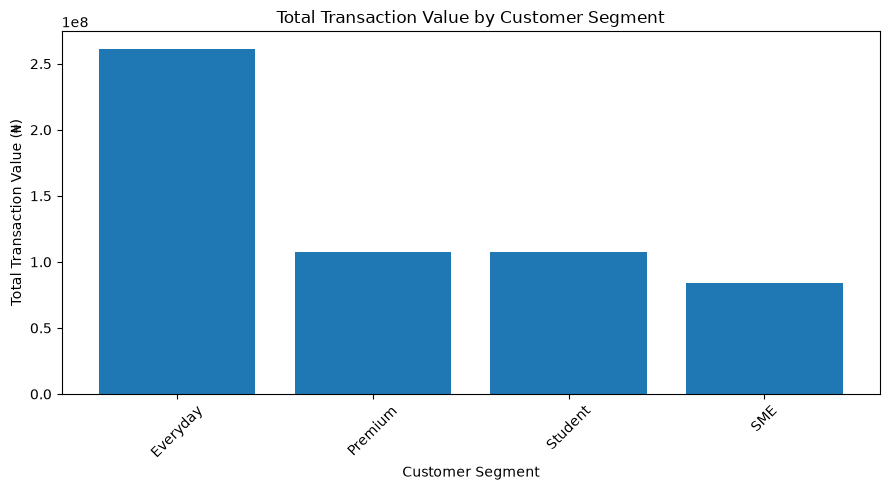

In [6]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS 2
# TITLE: Customer Segment Performance Comparison
# ==============================================================

# Load customer data
customers_df = pd.read_csv("Fintrust_Customer.csv")

# Merge customer segment information with transactions
segment_df = transactions_df.merge(
    customers_df[['Customer_ID', 'Customer_Segment']],
    on='Customer_ID',
    how='left'
)

# Calculate segment performance
segment_performance = (
    segment_df
    .groupby('Customer_Segment')
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),
        Total_Transaction_Value=('Amount_NGN', 'sum'),
        Average_Transaction_Amount=('Amount_NGN', 'mean')
    )
    .reset_index()
)

# Round numerical values
segment_performance[
    ['Total_Transaction_Value', 'Average_Transaction_Amount']
] = segment_performance[
    ['Total_Transaction_Value', 'Average_Transaction_Amount']
].round(2)

# Sort by total transaction value
segment_performance = segment_performance.sort_values(
    'Total_Transaction_Value',
    ascending=False
)

# Display results
display(segment_performance)

# Plot total transaction value by segment
plt.figure(figsize=(9, 5))

plt.bar(
    segment_performance['Customer_Segment'],
    segment_performance['Total_Transaction_Value']
)

plt.title('Total Transaction Value by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Transaction Value (₦)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Channel,Total_Transactions,Successful_Transactions,Total_Transaction_Value,Success_Rate
0,ATM,1747,1602,8.394235e+07,91.70
2,POS,2393,2174,1.043467e+08,90.85
4,Web,1869,1698,8.932500e+07,90.85
3,USSD,889,803,4.275895e+07,90.33
1,Mobile App,5102,4579,2.401044e+08,89.75


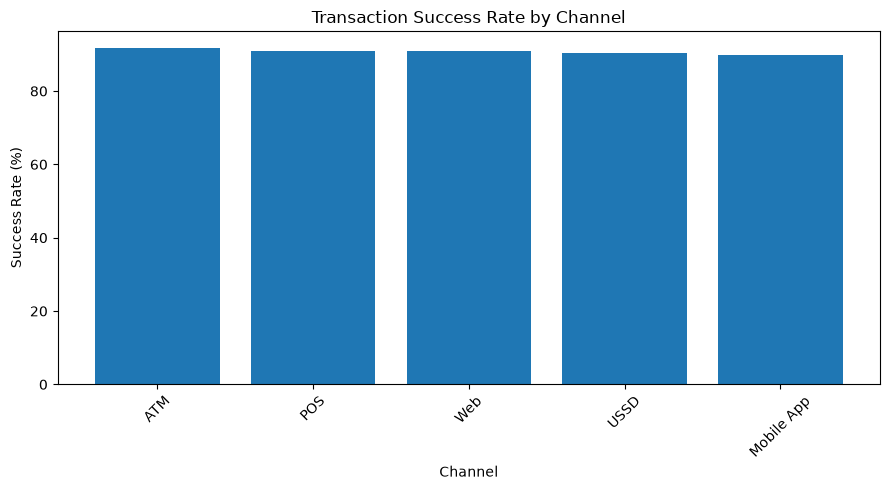

In [7]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS 3
# TITLE: Channel Performance Comparison
# ==============================================================

# Calculate channel performance
channel_performance = (
    transactions_df
    .groupby('Channel')
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),
        Successful_Transactions=(
            'Transaction_Status',
            lambda x: (x == 'Successful').sum()
        ),
        Total_Transaction_Value=('Amount_NGN', 'sum')
    )
    .reset_index()
)

# Calculate success rate
channel_performance['Success_Rate'] = (
    channel_performance['Successful_Transactions']
    / channel_performance['Total_Transactions']
    * 100
).round(2)

# Round transaction value
channel_performance['Total_Transaction_Value'] = (
    channel_performance['Total_Transaction_Value']
    .round(2)
)

# Sort by success rate
channel_performance = channel_performance.sort_values(
    'Success_Rate',
    ascending=False
)

# Display results
display(channel_performance)

# Plot success rate by channel
plt.figure(figsize=(9, 5))

plt.bar(
    channel_performance['Channel'],
    channel_performance['Success_Rate']
)

plt.title('Transaction Success Rate by Channel')
plt.xlabel('Channel')
plt.ylabel('Success Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

,Activity_Level,Total_Customers,Total_Transactions,Total_Transaction_Value,Average_Transaction_Value
0,Low Activity,500,2491,1.089232e+08,43678.40
1,Medium Activity,500,3929,1.876070e+08,47886.89
2,High Activity,500,5580,2.639471e+08,47269.34


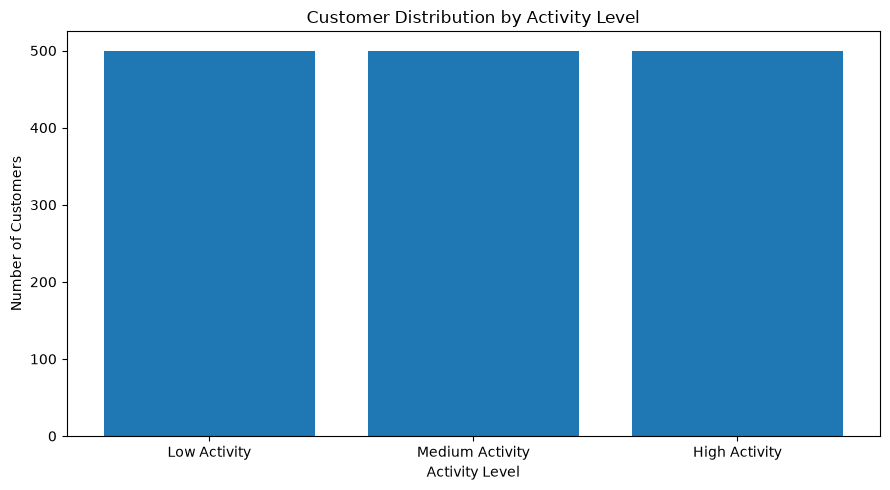

In [8]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS 4
# TITLE: Customer Activity Segmentation
# ==============================================================

# Calculate customer transaction activity
customer_activity = (
    segment_df
    .groupby(['Customer_ID', 'Customer_Segment'])
    .agg(
        Total_Transactions=('Transaction_ID', 'count'),
        Total_Transaction_Value=('Amount_NGN', 'sum'),
        Average_Transaction_Amount=('Amount_NGN', 'mean')
    )
    .reset_index()
)

# Create activity segments using transaction-frequency tertiles
customer_activity['Activity_Level'] = pd.qcut(
    customer_activity['Total_Transactions'].rank(
        method='first'
    ),
    q=3,
    labels=['Low Activity', 'Medium Activity', 'High Activity']
)

# Summarize activity levels
activity_summary = (
    customer_activity
    .groupby('Activity_Level', observed=True)
    .agg(
        Total_Customers=('Customer_ID', 'count'),
        Total_Transactions=('Total_Transactions', 'sum'),
        Total_Transaction_Value=('Total_Transaction_Value', 'sum'),
        Average_Transaction_Value=(
            'Average_Transaction_Amount', 'mean'
        )
    )
    .reset_index()
)

# Round numerical values
activity_summary[
    ['Total_Transaction_Value', 'Average_Transaction_Value']
] = activity_summary[
    ['Total_Transaction_Value', 'Average_Transaction_Value']
].round(2)

# Display results
display(activity_summary)

# Plot customer distribution by activity level
plt.figure(figsize=(9, 5))

plt.bar(
    activity_summary['Activity_Level'].astype(str),
    activity_summary['Total_Customers']
)

plt.title('Customer Distribution by Activity Level')
plt.xlabel('Activity Level')
plt.ylabel('Number of Customers')
plt.tight_layout()
plt.show()

In [9]:
# ==============================================================
# FINTRUST WEEK 3 — PYTHON ANALYSIS 5
# TITLE: Validation of Week 2 Customer Segment Finding
# ==============================================================

# Calculate transaction value by customer segment
validation = (
    segment_df
    .groupby('Customer_Segment')
    .agg(
        Total_Transaction_Value=('Amount_NGN', 'sum'),
        Total_Transactions=('Transaction_ID', 'count')
    )
    .reset_index()
)

# Round transaction values
validation['Total_Transaction_Value'] = (
    validation['Total_Transaction_Value'].round(2)
)

# Identify the segment with the highest transaction value
highest_value_segment = validation.loc[
    validation['Total_Transaction_Value'].idxmax()
]

# Display validation results
display(validation.sort_values(
    'Total_Transaction_Value',
    ascending=False
))

print(
    f"Highest transaction-value segment: "
    f"{highest_value_segment['Customer_Segment']}"
)

print(
    f"Transaction value: ₦"
    f"{highest_value_segment['Total_Transaction_Value']:,.2f}"
)

# Validation check
expected_segment = "Everyday"

if highest_value_segment['Customer_Segment'] == expected_segment:
    print("VALIDATION RESULT: Week 2 finding is confirmed.")
else:
    print("VALIDATION RESULT: Week 2 finding is not confirmed.")

,Customer_Segment,Total_Transaction_Value,Total_Transactions
0,Everyday,2.614589e+08,5644
1,Premium,1.077512e+08,2361
3,Student,1.074759e+08,2289
2,SME,8.379137e+07,1706


Highest transaction-value segment: Everyday
Transaction value: ₦261,458,920.99
VALIDATION RESULT: Week 2 finding is confirmed.
